<a href="https://www.kaggle.com/code/subhadiphensh/cat-vs-dog-classifier-cnn?scriptVersionId=287101109" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
!pip install -q "protobuf<4" --no-deps

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 4.4 MB/s eta 0:00:00a 0:00:01


In [2]:
!nvidia-smi

Thu Dec 18 16:27:30 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.172.08             Driver Version: 570.172.08     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [24]:
import os
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from tensorflow.keras import layers, models, Input
from tensorflow.keras.layers import Input, Rescaling, Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tqdm import tqdm
import shutil
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [4]:
DATA_DIR = "/kaggle/input/cats-vs-dogs-cnn/Cats_Dogs"
CLEAN_DIR = "/kaggle/working/CleanPetImages"

## **Cleaning the Data**

In [5]:
os.makedirs(CLEAN_DIR, exist_ok = True)

for category in ['cats', 'dogs']:
    src_folder = os.path.join(DATA_DIR, category)
    dest_folder = os.path.join(CLEAN_DIR, category)
    os.makedirs(dest_folder, exist_ok = True)

    for file in tqdm(os.listdir(src_folder), desc = f"Processing {category} images"):
        src_path = os.path.join(src_folder, file)
        dest_path = os.path.join(dest_folder, file)
        try:
            with Image.open(src_path) as img:
                img = img.convert("RGB")
                img.save(dest_path, "JPEG")
        except Exception:
            continue

print(f"Clean Dataset ready at : {CLEAN_DIR}")

Processing dogs images: 100%|██████████| 1000/1000 [00:06<00:00, 145.89it/s]

Clean Dataset ready at : /kaggle/working/CleanPetImages


In [6]:
for category in ['cats', 'dogs']:
    path = os.path.join(CLEAN_DIR, category)
    print(f"Total {category} : {len(os.listdir(path))}")

Total cats : 1000
Total dogs : 1000


## **Data Augmentation**

In [7]:
def augment_dataset(clean_dir, img_size = (224, 224), augmentations_per_image = 4, batch_size = 1):
    """
    Performs offline augmentation on images in the specified directory.
    
    Args:
        clean_dir (str): Path to the dataset directory containing class subfolders.
        img_size (tuple): Target size for the images (height, width).
        augmentations_per_image (int): Number of augmented versions to generate per original image.
        batch_size (int): Batch size for the generator (defaults to 1 for per-image processing).
    """
    
    datagen = keras.preprocessing.image.ImageDataGenerator(
        rotation_range = 30,
        width_shift_range = 0.2,
        height_shift_range = 0.2,
        shear_range = 0.2,
        zoom_range = 0.2,
        horizontal_flip = True,
        fill_mode = 'nearest'
    )

    categories = ['cats', 'dogs']

    for category in categories:
        folder_path = os.path.join(clean_dir, category)
        
        if not os.path.exists(folder_path):
            print(f"Warning: Directory {folder_path} not found. Skipping.")
            continue

        images = os.listdir(folder_path)
        print(f"Augmenting {category} images in {folder_path}...")

        processed_count = 0
        
        for img_name in tqdm(images):
            if img_name.startswith('aug'):
                continue
                
            img_path = os.path.join(folder_path, img_name)
            
            try:
                img = keras.utils.load_img(img_path, target_size = img_size)
                x = keras.utils.img_to_array(img)
                x = x.reshape((1, ) + x.shape)

                i = 0
                for batch in datagen.flow(x, 
                                          batch_size = batch_size, 
                                          save_to_dir = folder_path, 
                                          save_prefix = 'aug', 
                                          save_format = 'jpeg'):
                    i += 1
                    if i >= augmentations_per_image:
                        break
                
                processed_count += 1
                
            except Exception as e:
                print(f"Error processing {img_name}: {e}")

    print("\n-------------------------------------------")
    print("Augmentation Completed Successfully!")
    print("-------------------------------------------")

In [8]:
if __name__ == "__main__":
    IMG_SIZE = (224, 224)
    BATCH_SIZE = 1
    AUGMENTATIONS_PER_IMAGE = 4
    
    augment_dataset(
        clean_dir = CLEAN_DIR,
        img_size = IMG_SIZE,
        augmentations_per_image = AUGMENTATIONS_PER_IMAGE,
        batch_size = BATCH_SIZE
    )

Augmenting cats images in /kaggle/working/CleanPetImages/cats...


100%|██████████| 1000/1000 [00:43<00:00, 23.11it/s]


Augmenting dogs images in /kaggle/working/CleanPetImages/dogs...


100%|██████████| 1000/1000 [00:42<00:00, 23.34it/s]


-------------------------------------------
Augmentation Completed Successfully!
-------------------------------------------


In [9]:
for category in ['cats', 'dogs']:
    path = os.path.join(CLEAN_DIR, category)
    print(f"Total {category} : {len(os.listdir(path))}")

Total cats : 4298
Total dogs : 4288


## **Training and Validation Split**

In [10]:
IMG_SIZE = (224, 224)   
BATCH_SIZE = 32 
SEED = 1337 

print("------------------------------------------------")
print("Loading and Splitting Data...")
print("------------------------------------------------")

train_ds = keras.utils.image_dataset_from_directory(
    CLEAN_DIR,
    validation_split = 0.2,
    subset = 'training',
    seed = SEED,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    label_mode = 'categorical'
)


val_ds = keras.utils.image_dataset_from_directory(
    CLEAN_DIR,
    validation_split = 0.2,
    subset = 'validation',
    seed = SEED,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    label_mode = 'categorical'
)

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size = tf.data.AUTOTUNE)

print("------------------------------------------------")
print("Data is Ready")
print(f"Training Batches : {len(train_ds)}")
print(f"Testing Batches : {len(val_ds)}")
print("------------------------------------------------")

------------------------------------------------
Loading and Splitting Data...
------------------------------------------------
Found 8586 files belonging to 2 classes.
Using 6869 files for training.


I0000 00:00:1766075365.808933      98 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1766075365.812897      98 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 8586 files belonging to 2 classes.
Using 1717 files for validation.
------------------------------------------------
Data is Ready
Training Batches : 215
Testing Batches : 54
------------------------------------------------


In [11]:
print("\n--- Shape Check ---")
for images, labels in train_ds.take(1):
    print(f"Image Batch Shape: {images.shape}")
    print(f"Label Batch Shape: {labels.shape}") 
    break
print("-------------------\n")


--- Shape Check ---
Image Batch Shape: (32, 224, 224, 3)
Label Batch Shape: (32, 2)
-------------------



## **Model Building**

In [12]:
def build_model(input_shape = (224, 224, 3)):
    model = Sequential(
        [
            Input(shape = input_shape),
            Rescaling(1./255),

            Conv2D(32, kernel_size = (3, 3), padding = 'same', activation = 'relu'),
            BatchNormalization(),
            MaxPooling2D(pool_size = (2, 2)),

            Conv2D(64, kernel_size = (3, 3), padding = 'same', activation = 'relu'),
            BatchNormalization(),
            MaxPooling2D(pool_size = (2, 2)),
            Dropout(0.2),

            Conv2D(128, kernel_size = (3, 3), padding = 'same', activation = 'relu'),
            BatchNormalization(),
            MaxPooling2D(pool_size = (2, 2)),
            Dropout(0.3),

            Conv2D(256, kernel_size = (3, 3), padding = 'same', activation = 'relu'),
            BatchNormalization(),
            MaxPooling2D(pool_size = (2, 2)),
            Dropout(0.4),

            Flatten(),
            
            Dense(512, activation = 'relu'),
            BatchNormalization(),
            Dropout(0.5),

            Dense(128, activation = 'relu'),
            BatchNormalization(),

            Dense(2, activation = 'softmax')
        ]
    )

    model.compile(
        optimizer = 'SGD',
        loss = 'categorical_crossentropy',
        metrics = ['accuracy']
    )

    return model

In [13]:
model = build_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 26,149,442 (99.75 MB)

 Trainable params: 26,147,202 (99.74 MB)

 Non-trainable params: 2,240 (8.75 KB)

In [18]:
callbacks = [
    ModelCheckpoint(
        "best_model.keras", 
        save_best_only = True, 
        monitor = "val_accuracy", 
        mode = "max"
    ),
    
    EarlyStopping(
        monitor = "val_loss", 
        patience = 10, 
        restore_best_weights = True
    ),
    
    ReduceLROnPlateau(
        monitor = "val_loss",
        factor = 0.5, 
        patience = 3, 
        min_lr = 0.00001)
]

In [20]:
EPOCHS = 50

print("Starting Training...")

history = model.fit(
    train_ds,
    epochs = EPOCHS,
    validation_data = val_ds,
    # callbacks = callbacks      # not using coz due to SGD callbacks terminating the model in a very early prematured stage
)

Starting Training...
Epoch 1/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 16s 75ms/step - accuracy: 0.7108 - loss: 0.5537 - val_accuracy: 0.5818 - val_loss: 1.3701
Epoch 2/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 16s 76ms/step - accuracy: 0.7103 - loss: 0.5459 - val_accuracy: 0.6022 - val_loss: 1.5825
Epoch 3/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 16s 76ms/step - accuracy: 0.7198 - loss: 0.5455 - val_accuracy: 0.5888 - val_loss: 1.7995
Epoch 4/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 16s 75ms/step - accuracy: 0.7209 - loss: 0.5409 - val_accuracy: 0.5929 - val_loss: 1.9029
Epoch 5/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 16s 75ms/step - accuracy: 0.7436 - loss: 0.5214 - val_accuracy: 0.6057 - val_loss: 1.7506
Epoch 6/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 16s 75ms/step - accuracy: 0.7327 - loss: 0.5278 - val_accuracy: 0.6010 - val_loss: 1.9407
Epoch 7/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 16s 75ms/step - accuracy: 0.7249 - loss: 0.5347 - val_accuracy: 0.6045 - val_loss: 1.8297
Epoch 8/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 16s 76ms/step - accuracy: 0.7

In [22]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

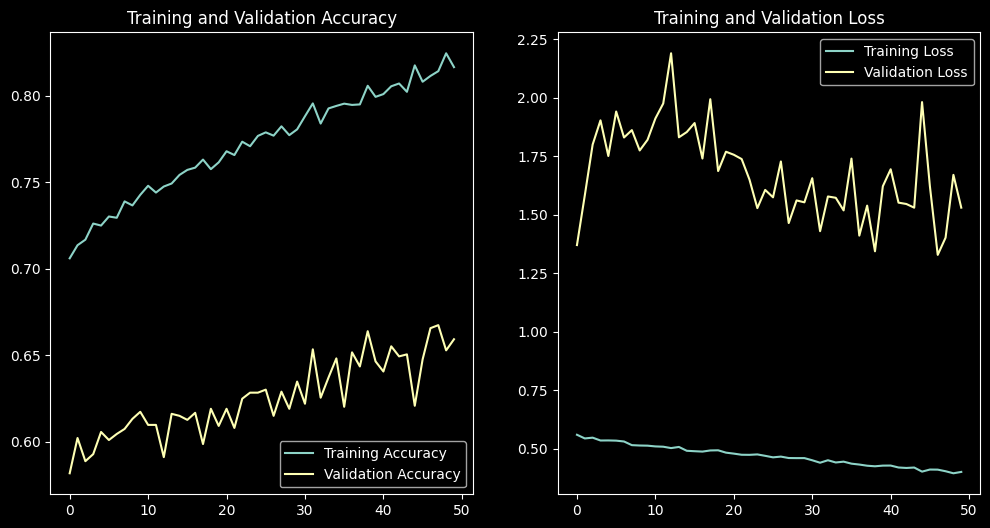

In [23]:
plt.style.use('dark_background')
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label = 'Training Accuracy')
plt.plot(epochs_range, val_acc, label = 'Validation Accuracy')
plt.legend(loc = 'lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label = 'Training Loss')
plt.plot(epochs_range, val_loss, label = 'Validation Loss')
plt.legend(loc = 'upper right')
plt.title('Training and Validation Loss')
plt.show()

## **As we can see model is overfitting which is not good. So trying a custom CNN mdodel for best performance.**

In [25]:
def entry_flow(x):
    x = layers.Conv2D(32, 3, strides = 2, padding = 'same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(64, 3, padding = 'same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    previous_block_activation = x
    x = layers.SeparableConv2D(128, 3, padding = 'same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.SeparableConv2D(128, 3, padding = 'same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(3, strides = 2, padding = 'same')(x)
    
    residual = layers.Conv2D(128, 1, strides = 2, padding = 'same')(previous_block_activation)
    residual = layers.BatchNormalization()(residual)
    x = layers.add([x, residual])

    previous_block_activation = x
    x = layers.Activation('relu')(x)
    x = layers.SeparableConv2D(256, 3, padding = 'same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.SeparableConv2D(256, 3, padding = 'same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(3, strides=2, padding = 'same')(x)
    
    residual = layers.Conv2D(256, 1, strides = 2, padding = 'same')(previous_block_activation)
    residual = layers.BatchNormalization()(residual)
    x = layers.add([x, residual])

    previous_block_activation = x
    x = layers.Activation('relu')(x)
    x = layers.SeparableConv2D(728, 3, padding = 'same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.SeparableConv2D(728, 3, padding = 'same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(3, strides = 2, padding = 'same')(x)
    
    residual = layers.Conv2D(728, 1, strides = 2, padding = 'same')(previous_block_activation)
    residual = layers.BatchNormalization()(residual)
    x = layers.add([x, residual])

    return x

In [26]:
def middle_flow(x):
    for _ in range(8):
        previous_block_activation = x
        
        x = layers.Activation('relu')(x)
        x = layers.SeparableConv2D(728, 3, padding = 'same')(x)
        x = layers.BatchNormalization()(x)
        
        x = layers.Activation('relu')(x)
        x = layers.SeparableConv2D(728, 3, padding = 'same')(x)
        x = layers.BatchNormalization()(x)
        
        x = layers.Activation('relu')(x)
        x = layers.SeparableConv2D(728, 3, padding = 'same')(x)
        x = layers.BatchNormalization()(x)
        
        x = layers.add([x, previous_block_activation])
        
    return x

In [27]:
def exit_flow(x):
    previous_block_activation = x
    
    x = layers.Activation('relu')(x)
    x = layers.SeparableConv2D(728, 3, padding = 'same')(x)
    x = layers.BatchNormalization()(x)
    
    x = layers.Activation('relu')(x)
    x = layers.SeparableConv2D(1024, 3, padding = 'same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(3, strides = 2, padding = 'same')(x)
    
    residual = layers.Conv2D(1024, 1, strides = 2, padding = 'same')(previous_block_activation)
    residual = layers.BatchNormalization()(residual)
    x = layers.add([x, residual])
    
    x = layers.SeparableConv2D(1536, 3, padding = 'same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    x = layers.SeparableConv2D(2048, 3, padding = 'same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    return x

In [28]:
def build_xception_model(input_shape):
    inputs = Input(shape = input_shape)
    
    x = layers.Rescaling(1./255)(inputs)
    
    x = entry_flow(x)
    x = middle_flow(x)
    x = exit_flow(x)
    
    x = layers.GlobalAveragePooling2D()(x)
    
    x = layers.Dropout(0.5)(x) 
    
    outputs = layers.Dense(2, activation = 'softmax')(x)
    
    model = models.Model(inputs, outputs, name = "Xception_CatsDogs")
    return model


In [29]:
INPUT_SHAPE = (224, 224, 3)

model_CNN = build_xception_model(INPUT_SHAPE)

model_CNN.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
model_CNN.summary()

Model: "Xception_CatsDogs"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 112, 112,  │        896 │ rescaling_1[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        128 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 112, 112,  │     18,496 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 112, 112,  │      8,896 │ activation_1[0][… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        512 │ separable_conv2d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 112, 112,  │     17,664 │ activation_2[0][… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        512 │ separable_conv2d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 56, 56,    │      8,320 │ activation_1[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        512 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 56, 56,    │          0 │ max_pooling2d_4[

 Total params: 20,892,842 (79.70 MB)

 Trainable params: 20,838,314 (79.49 MB)

 Non-trainable params: 54,528 (213.00 KB)

In [32]:
history_CNN = model_CNN.fit(
    train_ds,
    epochs = 10,
    validation_data = val_ds
)

Epoch 1/10


2025-12-18 17:10:21.195031: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-18 17:10:21.379963: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-18 17:10:23.581463: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-18 17:10:23.720985: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-18 17:10:24.905267: E external/local_xla/xla/stream_

130/215 ━━━━━━━━━━━━━━━━━━━━ 42s 495ms/step - accuracy: 0.5407 - loss: 0.7983

2025-12-18 17:12:11.432576: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-18 17:12:11.598357: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-18 17:12:12.897327: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-18 17:12:13.033348: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-18 17:12:13.890244: E external/local_xla/xla/stream_

215/215 ━━━━━━━━━━━━━━━━━━━━ 246s 743ms/step - accuracy: 0.5520 - loss: 0.7784 - val_accuracy: 0.5044 - val_loss: 0.6929
Epoch 2/10
215/215 ━━━━━━━━━━━━━━━━━━━━ 112s 521ms/step - accuracy: 0.6539 - loss: 0.6596 - val_accuracy: 0.5090 - val_loss: 0.9672
Epoch 3/10
215/215 ━━━━━━━━━━━━━━━━━━━━ 111s 519ms/step - accuracy: 0.7023 - loss: 0.6006 - val_accuracy: 0.6290 - val_loss: 6.4103
Epoch 4/10
215/215 ━━━━━━━━━━━━━━━━━━━━ 112s 521ms/step - accuracy: 0.7352 - loss: 0.5501 - val_accuracy: 0.6919 - val_loss: 0.6820
Epoch 5/10
215/215 ━━━━━━━━━━━━━━━━━━━━ 112s 523ms/step - accuracy: 0.7863 - loss: 0.4805 - val_accuracy: 0.6191 - val_loss: 0.9235
Epoch 6/10
215/215 ━━━━━━━━━━━━━━━━━━━━ 112s 520ms/step - accuracy: 0.7962 - loss: 0.4602 - val_accuracy: 0.7810 - val_loss: 0.5575
Epoch 7/10
215/215 ━━━━━━━━━━━━━━━━━━━━ 112s 521ms/step - accuracy: 0.8210 - loss: 0.4033 - val_accuracy: 0.7187 - val_loss: 0.6990
Epoch 8/10
215/215 ━━━━━━━━━━━━━━━━━━━━ 113s 524ms/step - accuracy: 0.8392 - loss: 0.37

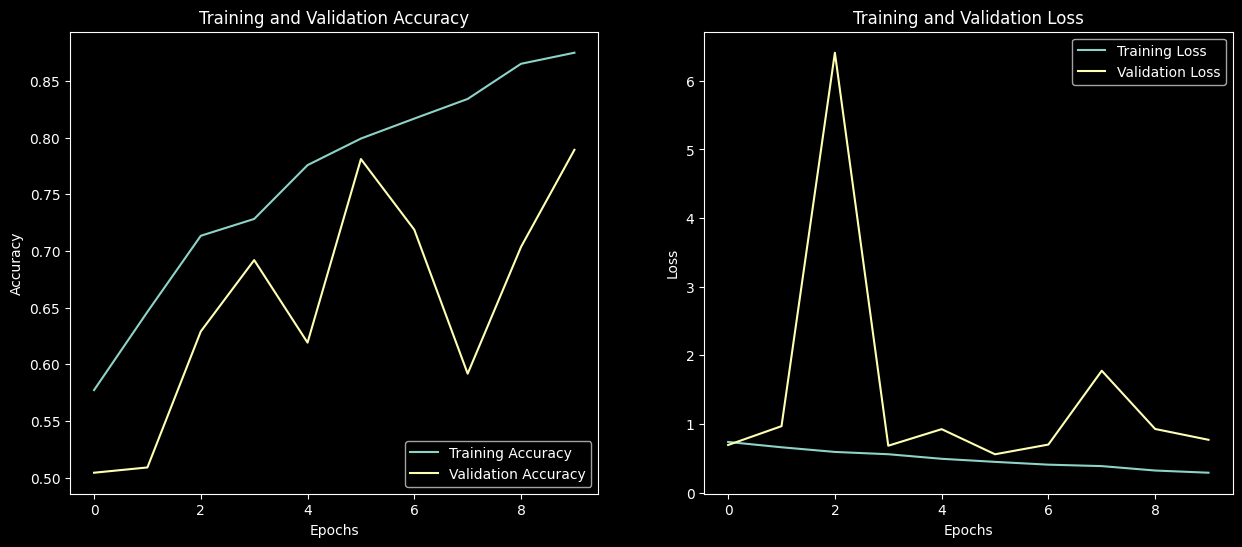

In [38]:
acc = history_CNN.history['accuracy']
val_acc = history_CNN.history['val_accuracy']
loss = history_CNN.history['loss']
val_loss = history_CNN.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize = (15, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label = 'Training Accuracy')
plt.plot(epochs_range, val_acc, label = 'Validation Accuracy')
plt.legend(loc = 'lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label = 'Training Loss')
plt.plot(epochs_range, val_loss, label = 'Validation Loss')
plt.legend(loc = 'upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.show()

## Project Conclusion

We successfully implemented the **Xception architecture from scratch** using **TensorFlow/Keras** to classify images from the **Cats vs. Dogs** dataset. The model demonstrated strong feature extraction capabilities; however, the observed variance between training and validation metrics highlights the importance of robust data augmentation and regularization strategies to ensure better generalization on unseen data.

---

## Future Scope & Recommendations

### Transfer Learning Integration  
To achieve near state-of-the-art accuracy with fewer training epochs, it is recommended to initialize the model using ImageNet pre-trained weights instead of training from random initialization.

### Hyperparameter Optimization  
Leverage automated tuning frameworks such as Keras Tuner to systematically identify optimal values for:
- Learning rate  
- Dropout rates  
- Batch size  

This approach can significantly reduce validation loss and improve convergence stability.

### Ensemble Methods  
Enhance classification robustness by combining predictions from this Xception model with other powerful architectures such as ResNet50 or EfficientNet, helping to reduce variance and improve overall performance.

---

## Reference & Attribution

This implementation is based on the Xception architecture proposed by François Chollet, the creator of Keras. The architecture replaces traditional Inception modules with depthwise separable convolutions, resulting in improved computational efficiency and performance.

**Original Research Paper:**  
[Xception: Deep Learning with Depthwise Separable Convolutions arXiv:1610.02357](https://arxiv.org/abs/1610.02357)
